In [1]:
%matplotlib inline
import openmc
import os
import numpy as np
import math

## 1. Assigning Phantom’s physical characteristics 

In [2]:
m1 = openmc.Material(material_id=1, name='m1')  # Skeletal bone
m1.set_density('g/cm3', 1.92)
m1.add_nuclide('H1', 0.0360, 'wo')
m1.add_nuclide('C0', 0.1590, 'wo')
m1.add_nuclide('N14', 0.0420, 'wo')
m1.add_nuclide('O16', 0.4480, 'wo')
m1.add_nuclide('Na23', 0.0030, 'wo')
m1.add_nuclide('Mg24', 0.0020, 'wo')
m1.add_nuclide('P31', 0.0940, 'wo')
m1.add_nuclide('S32', 0.0030, 'wo')
m1.add_nuclide('Ca40', 0.2130, 'wo')

m2 = openmc.Material(material_id=2, name='m2')  # Skin
m2.set_density('g/cm3', 1.09)
m2.add_nuclide('H1', 0.1000, 'wo')
m2.add_nuclide('C0', 0.1990, 'wo')
m2.add_nuclide('N14', 0.0420, 'wo')
m2.add_nuclide('O16', 0.6500, 'wo')
m2.add_nuclide('Na23', 0.0020, 'wo')
m2.add_nuclide('P31', 0.0010, 'wo')
m2.add_nuclide('S32', 0.0020, 'wo')
m2.add_nuclide('Cl35', 0.0030, 'wo')
m2.add_nuclide('K39', 0.0010, 'wo')

m3 = openmc.Material(material_id=3, name='m3')  # Lungs
m3.set_density('g/cm3', 0.385)
m3.add_nuclide('H1', 0.1030, 'wo')
m3.add_nuclide('C0', 0.1070, 'wo')
m3.add_nuclide('N14', 0.0320, 'wo')
m3.add_nuclide('O16', 0.7460, 'wo')
m3.add_nuclide('Na23', 0.0020, 'wo')
m3.add_nuclide('P31', 0.0020, 'wo')
m3.add_nuclide('S32', 0.0030, 'wo')
m3.add_nuclide('Cl35', 0.0030, 'wo')
m3.add_nuclide('K39', 0.0020, 'wo')

m4 = openmc.Material(material_id=4, name='m4')  # Brain
m4.set_density('g/cm3', 1.05)
m4.add_nuclide('H1', 0.1070, 'wo')
m4.add_nuclide('C0', 0.1440, 'wo')
m4.add_nuclide('N14', 0.0220, 'wo')
m4.add_nuclide('O16', 0.7130, 'wo')
m4.add_nuclide('Na23', 0.0020, 'wo')
m4.add_nuclide('P31', 0.0040, 'wo')
m4.add_nuclide('S32', 0.0020, 'wo')
m4.add_nuclide('Cl35', 0.0030, 'wo')
m4.add_nuclide('K39', 0.0030, 'wo')

m5 = openmc.Material(material_id=5, name='m5')  # Spinal cord
m5.set_density('g/cm3', 1.05)
m5.add_nuclide('H1', 0.1070, 'wo')
m5.add_nuclide('C0', 0.1440, 'wo')
m5.add_nuclide('N14', 0.0220, 'wo')
m5.add_nuclide('O16', 0.7130, 'wo')
m5.add_nuclide('Na23', 0.0020, 'wo')
m5.add_nuclide('P31', 0.0040, 'wo')
m5.add_nuclide('S32', 0.0020, 'wo')
m5.add_nuclide('Cl35', 0.0030, 'wo')
m5.add_nuclide('K39', 0.0030, 'wo')

m6 = openmc.Material(material_id=6, name='m6')  # Red bone marrow
m6.set_density('g/cm3', 1.03)
m6.add_nuclide('H1', 0.0900, 'wo')
m6.add_nuclide('C0', 0.4700, 'wo')
m6.add_nuclide('N14', 0.0170, 'wo')
m6.add_nuclide('O16', 0.3410, 'wo')
m6.add_nuclide('Na23', 0.0020, 'wo')
m6.add_nuclide('P31', 0.0220, 'wo')
m6.add_nuclide('S32', 0.0020, 'wo')
m6.add_nuclide('Cl35', 0.0010, 'wo')
m6.add_nuclide('Ca40', 0.0460, 'wo')

m7 = openmc.Material(material_id=7, name='m7')  # Liver
m7.set_density('g/cm3', 1.05)
m7.add_nuclide('H1', 0.1020, 'wo')
m7.add_nuclide('C0', 0.1310, 'wo')
m7.add_nuclide('N14', 0.0310, 'wo')
m7.add_nuclide('O16', 0.7240, 'wo')
m7.add_nuclide('Na23', 0.0020, 'wo')
m7.add_nuclide('P31', 0.0020, 'wo')
m7.add_nuclide('S32', 0.0030, 'wo')
m7.add_nuclide('Cl35', 0.0020, 'wo')
m7.add_nuclide('K39', 0.0030, 'wo')

m8 = openmc.Material(material_id=8, name='m8')  # Kidneys
m8.set_density('g/cm3', 1.05)
m8.add_nuclide('H1', 0.1030, 'wo')
m8.add_nuclide('C0', 0.1250, 'wo')
m8.add_nuclide('N14', 0.0310, 'wo')
m8.add_nuclide('O16', 0.7300, 'wo')
m8.add_nuclide('Na23', 0.0020, 'wo')
m8.add_nuclide('P31', 0.0020, 'wo')
m8.add_nuclide('S32', 0.0020, 'wo')
m8.add_nuclide('Cl35', 0.0020, 'wo')
m8.add_nuclide('K39', 0.0020, 'wo')
m8.add_nuclide('Ca40', 0.0010, 'wo')

m9 = openmc.Material(material_id=9, name='m9')  # Testes
m9.set_density('g/cm3', 1.05)
m9.add_nuclide('H1', 0.1030, 'wo')
m9.add_nuclide('C0', 0.1250, 'wo')
m9.add_nuclide('N14', 0.0310, 'wo')
m9.add_nuclide('O16', 0.7300, 'wo')
m9.add_nuclide('Na23', 0.0020, 'wo')
m9.add_nuclide('P31', 0.0020, 'wo')
m9.add_nuclide('S32', 0.0020, 'wo')
m9.add_nuclide('Cl35', 0.0020, 'wo')
m9.add_nuclide('K39', 0.0020, 'wo')
m9.add_nuclide('Ca40', 0.0010, 'wo')

m10 = openmc.Material(material_id=10, name='m10')  # Urinary bladder
m10.set_density('g/cm3', 1.04)
m10.add_nuclide('H1', 0.1050, 'wo')
m10.add_nuclide('C0', 0.0960, 'wo')
m10.add_nuclide('N14', 0.0260, 'wo')
m10.add_nuclide('O16', 0.7610, 'wo')
m10.add_nuclide('Na23', 0.0020, 'wo')
m10.add_nuclide('P31', 0.0020, 'wo')
m10.add_nuclide('S32', 0.0020, 'wo')
m10.add_nuclide('Cl35', 0.0030, 'wo')
m10.add_nuclide('K39', 0.0030, 'wo')

m11 = openmc.Material(material_id=11, name='m11')  # Gallbladder
m11.set_density('g/cm3', 1.03)
m11.add_nuclide('H1', 0.1050, 'wo')
m11.add_nuclide('C0', 0.2350, 'wo')
m11.add_nuclide('N14', 0.0280, 'wo')
m11.add_nuclide('O16', 0.6220, 'wo')
m11.add_nuclide('Na23', 0.0010, 'wo')
m11.add_nuclide('P31', 0.0020, 'wo')
m11.add_nuclide('S32', 0.0030, 'wo')
m11.add_nuclide('Cl35', 0.0020, 'wo')
m11.add_nuclide('K39', 0.0020, 'wo')

m12 = openmc.Material(material_id=12, name='m12')  # Heart
m12.set_density('g/cm3', 1.05)
m12.add_nuclide('H1', 0.1040, 'wo')
m12.add_nuclide('C0', 0.1380, 'wo')
m12.add_nuclide('N14', 0.0290, 'wo')
m12.add_nuclide('O16', 0.7190, 'wo')
m12.add_nuclide('Na23', 0.0010, 'wo')
m12.add_nuclide('P31', 0.0020, 'wo')
m12.add_nuclide('S32', 0.0020, 'wo')
m12.add_nuclide('Cl35', 0.0020, 'wo')
m12.add_nuclide('K39', 0.0030, 'wo')

m13 = openmc.Material(material_id=13, name='m13')  # Salivary glands
m13.set_density('g/cm3', 1.04)
m13.add_nuclide('H1', 0.1040, 'wo')
m13.add_nuclide('C0', 0.1180, 'wo')
m13.add_nuclide('N14', 0.0250, 'wo')
m13.add_nuclide('O16', 0.7450, 'wo')
m13.add_nuclide('Na23', 0.0020, 'wo')
m13.add_nuclide('P31', 0.0010, 'wo')
m13.add_nuclide('S32', 0.0010, 'wo')
m13.add_nuclide('Cl35', 0.0020, 'wo')
m13.add_nuclide('K39', 0.0010, 'wo')

m14 = openmc.Material(material_id=14, name='m14')  # Thymus
m14.set_density('g/cm3', 1.04)
m14.add_nuclide('H1', 0.1040, 'wo')
m14.add_nuclide('C0', 0.1180, 'wo')
m14.add_nuclide('N14', 0.0250, 'wo')
m14.add_nuclide('O16', 0.7450, 'wo')
m14.add_nuclide('Na23', 0.0020, 'wo')
m14.add_nuclide('P31', 0.0010, 'wo')
m14.add_nuclide('S32', 0.0010, 'wo')
m14.add_nuclide('Cl35', 0.0020, 'wo')
m14.add_nuclide('K39', 0.0010, 'wo')

m15 = openmc.Material(material_id=15, name='m15')  # Thyroid
m15.set_density('g/cm3', 1.04)
m15.add_nuclide('H1', 0.1040, 'wo')
m15.add_nuclide('C0', 0.1180, 'wo')
m15.add_nuclide('N14', 0.0250, 'wo')
m15.add_nuclide('O16', 0.7450, 'wo')
m15.add_nuclide('Na23', 0.0020, 'wo')
m15.add_nuclide('P31', 0.0010, 'wo')
m15.add_nuclide('S32', 0.0010, 'wo')
m15.add_nuclide('Cl35', 0.0020, 'wo')
m15.add_nuclide('K39', 0.0010, 'wo')

m16 = openmc.Material(material_id=16, name='m16')  # Oesophagus
m16.set_density('g/cm3', 1.03)
m16.add_nuclide('H1', 0.1040, 'wo')
m16.add_nuclide('C0', 0.2220, 'wo')
m16.add_nuclide('N14', 0.0280, 'wo')
m16.add_nuclide('O16', 0.6360, 'wo')
m16.add_nuclide('Na23', 0.0010, 'wo')
m16.add_nuclide('P31', 0.0020, 'wo')
m16.add_nuclide('S32', 0.0030, 'wo')
m16.add_nuclide('Cl35', 0.0020, 'wo')
m16.add_nuclide('K39', 0.0020, 'wo')

m17 = openmc.Material(material_id=17, name='m17')  # Spleen
m17.set_density('g/cm3', 1.04)
m17.add_nuclide('H1', 0.1030, 'wo')
m17.add_nuclide('C0', 0.1120, 'wo')
m17.add_nuclide('N14', 0.0320, 'wo')
m17.add_nuclide('O16', 0.7430, 'wo')
m17.add_nuclide('Na23', 0.0010, 'wo')
m17.add_nuclide('P31', 0.0020, 'wo')
m17.add_nuclide('S32', 0.0020, 'wo')
m17.add_nuclide('Cl35', 0.0020, 'wo')
m17.add_nuclide('K39', 0.0030, 'wo')

m18 = openmc.Material(material_id=18, name='m18')  # Pancreas
m18.set_density('g/cm3', 1.05)
m18.add_nuclide('H1', 0.1050, 'wo')
m18.add_nuclide('C0', 0.1570, 'wo')
m18.add_nuclide('N14', 0.0240, 'wo')
m18.add_nuclide('O16', 0.7050, 'wo')
m18.add_nuclide('Na23', 0.0020, 'wo')
m18.add_nuclide('P31', 0.0020, 'wo')
m18.add_nuclide('S32', 0.0010, 'wo')
m18.add_nuclide('Cl35', 0.0020, 'wo')
m18.add_nuclide('K39', 0.0020, 'wo')

m19 = openmc.Material(material_id=19, name='m19')  # Stomach
m19.set_density('g/cm3', 1.04)
m19.add_nuclide('H1', 0.1050, 'wo')
m19.add_nuclide('C0', 0.1140, 'wo')
m19.add_nuclide('N14', 0.0250, 'wo')
m19.add_nuclide('O16', 0.7500, 'wo')
m19.add_nuclide('Na23', 0.0010, 'wo')
m19.add_nuclide('P31', 0.0010, 'wo')
m19.add_nuclide('S32', 0.0010, 'wo')
m19.add_nuclide('Cl35', 0.0020, 'wo')
m19.add_nuclide('K39', 0.0010, 'wo')
m19.add_nuclide('I127', 0.0010, 'wo')

m20 = openmc.Material(material_id=20, name='m20')  # Adipose tissue
m20.set_density('g/cm3', 0.95)
m20.add_nuclide('H1', 0.1140, 'wo')
m20.add_nuclide('C0', 0.5890, 'wo')
m20.add_nuclide('N14', 0.0070, 'wo')
m20.add_nuclide('O16', 0.2870, 'wo')
m20.add_nuclide('Na23', 0.0010, 'wo')
m20.add_nuclide('S32', 0.0010, 'wo')
m20.add_nuclide('Cl35', 0.0010, 'wo')

m21 = openmc.Material(material_id=21, name='m21')  # Muscle tissue
m21.set_density('g/cm3', 1.05)
m21.add_nuclide('H1', 0.1020, 'wo')
m21.add_nuclide('C0', 0.1420, 'wo')
m21.add_nuclide('N14', 0.0340, 'wo')
m21.add_nuclide('O16', 0.7110, 'wo')
m21.add_nuclide('Na23', 0.0010, 'wo')
m21.add_nuclide('P31', 0.0020, 'wo')
m21.add_nuclide('S32', 0.0030, 'wo')
m21.add_nuclide('Cl35', 0.0010, 'wo')
m21.add_nuclide('K39', 0.0040, 'wo')

m22 = openmc.Material(material_id=22, name='m22')  # Breast
m22.set_density('g/cm3', 1.04)
m22.add_nuclide('H1', 0.0993, 'wo')
m22.add_nuclide('C0', 0.4610, 'wo')
m22.add_nuclide('N14', 0.0050, 'wo')
m22.add_nuclide('O16', 0.4200, 'wo')

m23 = openmc.Material(material_id=23, name='m23')  # Eye lenses
m23.set_density('g/cm3', 1.1)
m23.add_nuclide('H1', 0.0992, 'wo')
m23.add_nuclide('C0', 0.1937, 'wo')
m23.add_nuclide('N14', 0.0533, 'wo')
m23.add_nuclide('O16', 0.4200, 'wo')

m24 = openmc.Material(material_id=24, name='m24')  # Eyes
m24.set_density('g/cm3', 1.05)
m24.add_nuclide('H1', 0.0970, 'wo')
m24.add_nuclide('C0', 0.1830, 'wo')
m24.add_nuclide('N14', 0.0540, 'wo')
m24.add_nuclide('O16', 0.6600, 'wo')
m24.add_nuclide('Na23', 0.0010, 'wo')
m24.add_nuclide('P31', 0.0010, 'wo')
m24.add_nuclide('S32', 0.0030, 'wo')
m24.add_nuclide('Cl35', 0.0010, 'wo')

m25 = openmc.Material(material_id=25, name='m25')  # Prostate
m25.set_density('g/cm3', 1.04)
m25.add_nuclide('H1', 0.1030, 'wo')
m25.add_nuclide('C0', 0.1120, 'wo')
m25.add_nuclide('N14', 0.0320, 'wo')
m25.add_nuclide('O16', 0.7430, 'wo')
m25.add_nuclide('Na23', 0.0010, 'wo')
m25.add_nuclide('P31', 0.0020, 'wo')
m25.add_nuclide('S32', 0.0020, 'wo')
m25.add_nuclide('Cl35', 0.0020, 'wo')
m25.add_nuclide('K39', 0.0030, 'wo')

m26 = openmc.Material(material_id=26, name='m26')  # Adrenals
m26.set_density('g/cm3', 1.03)
m26.add_nuclide('H1', 0.1040, 'wo')
m26.add_nuclide('C0', 0.2280, 'wo')
m26.add_nuclide('N14', 0.0280, 'wo')
m26.add_nuclide('O16', 0.6300, 'wo')
m26.add_nuclide('Na23', 0.0010, 'wo')
m26.add_nuclide('P31', 0.0020, 'wo')
m26.add_nuclide('S32', 0.0030, 'wo')
m26.add_nuclide('Cl35', 0.0020, 'wo')
m26.add_nuclide('K39', 0.0020, 'wo')

m27 = openmc.Material(material_id=27, name='m27')  # Small intestine
m27.set_density('g/cm3', 1.04)
m27.add_nuclide('H1', 0.1050, 'wo')
m27.add_nuclide('C0', 0.1140, 'wo')
m27.add_nuclide('N14', 0.0250, 'wo')
m27.add_nuclide('O16', 0.7500, 'wo')
m27.add_nuclide('Na23', 0.0010, 'wo')
m27.add_nuclide('P31', 0.0010, 'wo')
m27.add_nuclide('S32', 0.0010, 'wo')
m27.add_nuclide('Cl35', 0.0020, 'wo')
m27.add_nuclide('K39', 0.0010, 'wo')

m28 = openmc.Material(material_id=28, name='m28')  # lower Colon
m28.set_density('g/cm3', 1.04)
m28.add_nuclide('H1', 0.1050, 'wo')
m28.add_nuclide('C0', 0.1140, 'wo')
m28.add_nuclide('N14', 0.0250, 'wo')
m28.add_nuclide('O16', 0.7500, 'wo')
m28.add_nuclide('Na23', 0.0010, 'wo')
m28.add_nuclide('P31', 0.0010, 'wo')
m28.add_nuclide('S32', 0.0010, 'wo')
m28.add_nuclide('Cl35', 0.0020, 'wo')
m28.add_nuclide('K39', 0.0010, 'wo')

m29 = openmc.Material(material_id=29, name='m29')  # Upper Colon
m29.set_density('g/cm3', 1.04)
m29.add_nuclide('H1', 0.1050, 'wo')
m29.add_nuclide('C0', 0.1140, 'wo')
m29.add_nuclide('N14', 0.0250, 'wo')
m29.add_nuclide('O16', 0.7500, 'wo')
m29.add_nuclide('Na23', 0.0010, 'wo')
m29.add_nuclide('P31', 0.0010, 'wo')
m29.add_nuclide('S32', 0.0010, 'wo')
m29.add_nuclide('Cl35', 0.0020, 'wo')
m29.add_nuclide('K39', 0.0010, 'wo')

m30 = openmc.Material(material_id=30, name='m30')  # Remainder
m30.set_density('g/cm3', 1.04)
m30.add_nuclide('H1', 0.1050, 'wo')
m30.add_nuclide('C0', 0.1140, 'wo')
m30.add_nuclide('N14', 0.0250, 'wo')
m30.add_nuclide('O16', 0.7500, 'wo')
m30.add_nuclide('Na23', 0.0010, 'wo')
m30.add_nuclide('P31', 0.0010, 'wo')
m30.add_nuclide('S32', 0.0010, 'wo')
m30.add_nuclide('Cl35', 0.0020, 'wo')
m30.add_nuclide('K39', 0.0010, 'wo')

m255 = openmc.Material(material_id=255, name='m255')  # Air
m255.set_density('g/cm3', 0.0012)
m255.add_nuclide('N14', 0.7555, 'wo')
m255.add_nuclide('O16', 0.2320, 'wo')
m255.add_nuclide('Ar40', 0.0130, 'wo')
for m in [m1, m2, m3, m4, m5, m6, m7, m8, m9, m10,
          m11, m12, m13, m14, m15, m16, m17, m18, m19, m20,
          m21, m22, m23, m24, m25, m26, m27, m28, m29, m30]:
    m.add_s_alpha_beta('c_H_in_H2O', fraction=1.0)   #

#
mat = openmc.Materials([m1, m2, m3, m4, m5, m6, m7, m8, m9, m10,
                        m11, m12, m13, m14, m15, m16, m17, m18, m19, m20,
                        m21, m22, m23, m24, m25, m26, m27, m28, m29, m30, m255])

mat.temperature = 293.6          # room temperature (K)

#mat.cross_sections = '/home/ali/endfb-vii.1-hdf5/cross_sections.xml'
#mat.export_to_xml()

## 2. Geometry definition 

In [3]:
# Cube 
px7  = openmc.XPlane(0.00000)
px8  = openmc.XPlane(0.20000)
py9  = openmc.YPlane(0.00000)
py10 = openmc.YPlane(0.20000)
pz11 = openmc.ZPlane(0.00000)
pz12 = openmc.ZPlane(0.20000)
region_cube = -px8 & +px7 & -py10 & +py9 & -pz12 & +pz11

# Lattice box 
px1 = openmc.XPlane(-69)
px2 = openmc.XPlane(68)
py3 = openmc.YPlane(-132)
py4 = openmc.YPlane(132)
pz5 = openmc.ZPlane(-450)
pz6 = openmc.ZPlane(449)

# AP SCORING PLANE 
x_plane = openmc.XPlane(x0=-40.0)
x_plan2 = openmc.XPlane(x0=-37.0)
y_min   = openmc.YPlane(y0=-27.0)
y_max   = openmc.YPlane(y0=27.0)
z_min   = openmc.ZPlane(z0=-90.0)
z_max   = openmc.ZPlane(z0=90.0)

for p in [x_plane, x_plan2, y_min, y_max, z_min, z_max]:
    p.boundary_type = 'transmission'

region_plane_ap = +x_plane & -x_plan2 & +y_min & -y_max & +z_min & -z_max


#  LLAT SCORING PLANE
y_plane_llat  = openmc.YPlane(y0=-40.0)
y_plan2_llat  = openmc.YPlane(y0=-37.0)

y_plane_llat.boundary_type = 'transmission'
y_plan2_llat.boundary_type = 'transmission'

region_plane_llat = (+y_plane_llat & -y_plan2_llat &
                     +px1 & -px2 & +z_min & -z_max)

# RLAT SCORING PLANE
y_plane_rlat  = openmc.YPlane(y0=+37.0)
y_plan2_rlat  = openmc.YPlane(y0=+40.0)

y_plane_rlat.boundary_type = 'transmission'
y_plan2_rlat.boundary_type = 'transmission'

region_plane_rlat = (+y_plane_rlat & -y_plan2_rlat &
                     +px1 & -px2 & +z_min & -z_max)

# LATTICE REGIONS 
region_lattice_ap   = (+px1 & -px2 & +py3 & -py4 & +pz5 & -pz6) & ~region_plane_ap
region_lattice_llat = (+px1 & -px2 & +py3 & -py4 & +pz5 & -pz6) & ~region_plane_llat
region_lattice_rlat = (+px1 & -px2 & +py3 & -py4 & +pz5 & -pz6) & ~region_plane_rlat

#
s909 = openmc.Sphere(x0=0.0, y0=0.0, z0=0, r=750, boundary_type='transmission')
outer_sphere = openmc.Sphere(x0=0.0, y0=0.0, z0=0, r=800, boundary_type='vacuum')

region_air1 = -s909 & ~region_lattice_ap & ~region_plane_ap
region_in   = +s909 & -outer_sphere
region_out  = +outer_sphere

### universes filling 

In [4]:
u1 = openmc.Universe(universe_id=1)  # Skeletal bone
u1.add_cell(openmc.Cell(fill=m1, region=-s909))

u2 = openmc.Universe(universe_id=2)  # Skin
u2.add_cell(openmc.Cell(fill=m2, region=-s909))

u3 = openmc.Universe(universe_id=3)  # Lungs
u3.add_cell(openmc.Cell(fill=m3, region=-s909))

u4 = openmc.Universe(universe_id=4)  # Brain
u4.add_cell(openmc.Cell(fill=m4, region=-s909))

u5 = openmc.Universe(universe_id=5)  # Spinal cord
u5.add_cell(openmc.Cell(fill=m5, region=-s909))

u6 = openmc.Universe(universe_id=6)  # Red bone marrow
u6.add_cell(openmc.Cell(fill=m6, region=-s909))

u7 = openmc.Universe(universe_id=7)  # Liver
u7.add_cell(openmc.Cell(fill=m7, region=-s909))

u8 = openmc.Universe(universe_id=8)  # Kidneys
u8.add_cell(openmc.Cell(fill=m8, region=-s909))

u9 = openmc.Universe(universe_id=9)  # Testes
u9.add_cell(openmc.Cell(fill=m9, region=-s909))

u10 = openmc.Universe(universe_id=10)  # Urinary bladder
u10.add_cell(openmc.Cell(fill=m10, region=-s909))

u11 = openmc.Universe(universe_id=11)  # Gallbladder
u11.add_cell(openmc.Cell(fill=m11, region=-s909))

u12 = openmc.Universe(universe_id=12)  # Heart
u12.add_cell(openmc.Cell(fill=m12, region=-s909))

u13 = openmc.Universe(universe_id=13)  # Salivary glands
u13.add_cell(openmc.Cell(fill=m13, region=-s909))

u14 = openmc.Universe(universe_id=14)  # Thymus
u14.add_cell(openmc.Cell(fill=m14, region=-s909))

u15 = openmc.Universe(universe_id=15)  # Thyroid
u15.add_cell(openmc.Cell(fill=m15, region=-s909))

u16 = openmc.Universe(universe_id=16)  # Oesophagus
u16.add_cell(openmc.Cell(fill=m16, region=-s909))

u17 = openmc.Universe(universe_id=17)  # Spleen
u17.add_cell(openmc.Cell(fill=m17, region=-s909))

u18 = openmc.Universe(universe_id=18)  # Pancreas
u18.add_cell(openmc.Cell(fill=m18, region=-s909))

u19 = openmc.Universe(universe_id=19)  # Stomach
u19.add_cell(openmc.Cell(fill=m19, region=-s909))

u20 = openmc.Universe(universe_id=20)  # Adipose tissue
u20.add_cell(openmc.Cell(fill=m20, region=-s909))

u21 = openmc.Universe(universe_id=21)  # Muscle tissue
u21.add_cell(openmc.Cell(fill=m21, region=-s909))

u22 = openmc.Universe(universe_id=22)  # Breast
u22.add_cell(openmc.Cell(fill=m22, region=-s909))

u23 = openmc.Universe(universe_id=23)  # Eye lenses
u23.add_cell(openmc.Cell(fill=m23, region=-s909))

u24 = openmc.Universe(universe_id=24)  # Eyes
u24.add_cell(openmc.Cell(fill=m24, region=-s909))

u25 = openmc.Universe(universe_id=25)  # Prostate
u25.add_cell(openmc.Cell(fill=m25, region=-s909))

u26 = openmc.Universe(universe_id=26)  # Adrenals
u26.add_cell(openmc.Cell(fill=m26, region=-s909))

u27 = openmc.Universe(universe_id=27)  # Small intestine
u27.add_cell(openmc.Cell(fill=m27, region=-s909))

u28 = openmc.Universe(universe_id=28)  # lower Colon
u28.add_cell(openmc.Cell(fill=m28, region=-s909))

u29 = openmc.Universe(universe_id=29)  # Upper Colon
u29.add_cell(openmc.Cell(fill=m29, region=-s909))


u30 = openmc.Universe(universe_id=30)  # Remainder
u30.add_cell(openmc.Cell(fill=m30, region=-s909))

u255 = openmc.Universe(universe_id=255)  # Air
u255.add_cell(openmc.Cell(fill=m255, region=-s909))

### Populating Universe indices

In [5]:
##########################
# 224 slices

In [6]:
# processe_openmc_lattice
def read_fill_card(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    result = []
    for line in lines:
        elements = line.strip().split()
        for element in elements:
            if 'r' in element:
                repeat_count = int(element[:-1])
                if result:
                    result.extend([result[-1]] * repeat_count)
            else:
                result.append(int(element))
    
    return result

file_path = 'svp2.txt'
array = read_fill_card(file_path)

openmc_universes = [[[0 for x in range(138)] for y in range(264)] for z in range(224)]
i = 0
for z in range(224):
    for y in range(264):
        for x in range(138):
            openmc_universes[z][y][x] = eval('u' + str(array[i]))
            i += 1

In [7]:
print(array[:200])  # Check the first 200 universe indices

[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255]

In [8]:
import numpy as np
import csv
voxel_array=array
voxel_size=(0.20, 0.20, 0.80)
def calculate_volumes(voxel_array, voxel_size=(0.20, 0.20, 0.80)):
    # Calculate the volume of a single voxel
    voxel_volume = np.prod(voxel_size)
    # universe IDs counts
    unique_universes, counts = np.unique(voxel_array, return_counts=True)
    # Calculate volumes
    volumes = {universe: count * voxel_volume for universe, count in zip(unique_universes, counts)}
    
    return volumes

#
volumes = calculate_volumes(voxel_array, voxel_size)
# 
for universe, volume in volumes.items():
    print(f"Universe {universe}: Volume = {volume:.3f} cm³")
#
# Save results to a CSV file
csv_file = 'volumes.csv'
with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Universe', 'Volume (cm³)'])  # Write header
    for universe, volume in volumes.items():
        writer.writerow([universe, f"{volume:.3f}"])


Universe 1: Volume = 7426.912 cm³
Universe 2: Volume = 4478.400 cm³
Universe 3: Volume = 2339.936 cm³
Universe 4: Volume = 1570.592 cm³
Universe 5: Volume = 111.712 cm³
Universe 6: Volume = 251.744 cm³
Universe 7: Volume = 1308.736 cm³
Universe 8: Volume = 319.584 cm³
Universe 9: Volume = 29.120 cm³
Universe 10: Volume = 62.912 cm³
Universe 11: Volume = 14.432 cm³
Universe 12: Volume = 762.240 cm³
Universe 13: Volume = 56.384 cm³
Universe 14: Volume = 18.848 cm³
Universe 15: Volume = 9.088 cm³
Universe 16: Volume = 23.840 cm³
Universe 17: Volume = 247.008 cm³
Universe 18: Volume = 107.840 cm³
Universe 19: Volume = 411.328 cm³
Universe 20: Volume = 25260.832 cm³
Universe 21: Volume = 27924.576 cm³
Universe 22: Volume = 0.992 cm³
Universe 23: Volume = 0.128 cm³
Universe 24: Volume = 19.840 cm³
Universe 25: Volume = 97.024 cm³
Universe 26: Volume = 4.032 cm³
Universe 27: Volume = 1780.160 cm³
Universe 28: Volume = 74.816 cm³
Universe 29: Volume = 499.264 cm³
Universe 30: Volume = 39.968 c

## 3. Lattice definition and cell card  

In [9]:
# Lattice definitions
outer_universe = openmc.Universe()
lat3d = openmc.RectLattice(name='Saudi Phantom')
lat3d.lower_left = (-13.8, -26.4, -89.600)
lat3d.upper_right = (13.8, 26.6 , 89.600)
lat3d.pitch = (0.2000, 0.2000, 0.8000) # z= 0.8 cm
lat3d.universes = openmc_universes
lat3d.outer = u255

################################################################
# AP 
cell_lat_ap   = openmc.Cell(fill=lat3d, region=region_lattice_ap)
plane_cell_ap = openmc.Cell(fill=u255, region=region_plane_ap)

# LLAT
cell_lat_llat   = openmc.Cell(fill=lat3d, region=region_lattice_llat)
plane_cell_llat = openmc.Cell(fill=u255, region=region_plane_llat)

# RLAT
cell_lat_rlat   = openmc.Cell(fill=lat3d, region=region_lattice_rlat)
plane_cell_rlat = openmc.Cell(fill=u255, region=region_plane_rlat)

# Common cells (air, inside sphere, outside sphere)
cell_in   = openmc.Cell(fill=m255,       region=region_air1)
cell_in2  = openmc.Cell(region=region_in)
cell_out  = openmc.Cell(region=region_out)

################################################################## 
# AP geometry
# root = openmc.Universe(cells=[cell_lat_ap, cell_in, plane_cell_ap, cell_in2, cell_out])
# my_geometry = openmc.Geometry(root)

################################################################## 
# LLAT geometry
root = openmc.Universe(cells=[cell_lat_llat, cell_in, plane_cell_llat, cell_in2, cell_out])
my_geometry = openmc.Geometry(root)

################################################################## 
# RLAT geometry 
#root = openmc.Universe(cells=[cell_lat_rlat, cell_in, plane_cell_rlat, cell_in2, cell_out])
#my_geometry = openmc.Geometry(root)


#my_geometry.export_to_xml()

In [10]:
# settings = openmc.Settings()
# settings.material_cell_offsets = False

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

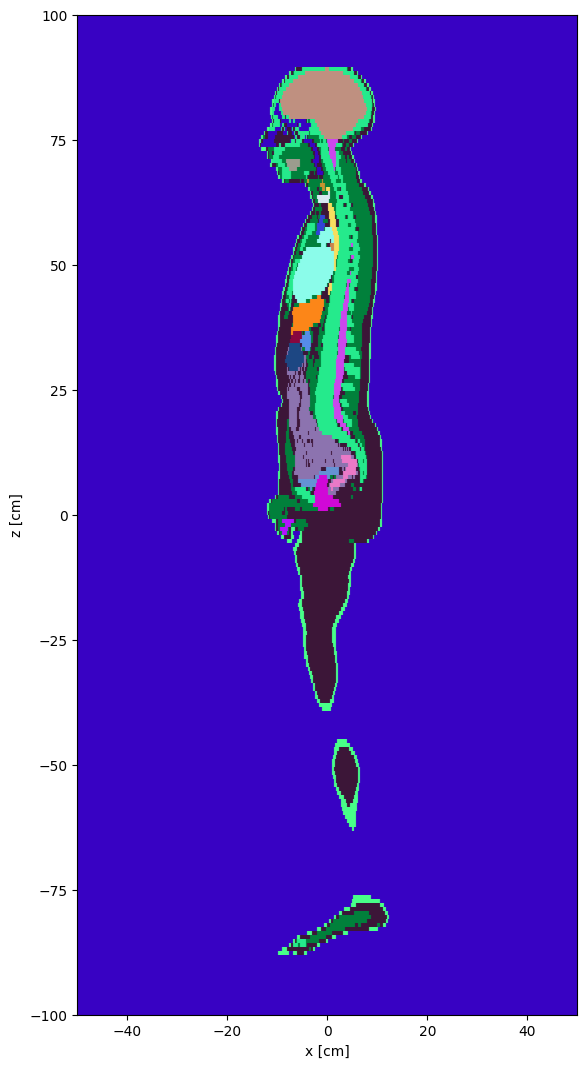

In [11]:
# plot
root.plot(
    basis = 'xz',
    origin = (0, 0, 0),
    color_by = 'cell',
    width=(100,200),
    pixels = (1000, 1000)
)

<Axes: xlabel='y [cm]', ylabel='z [cm]'>

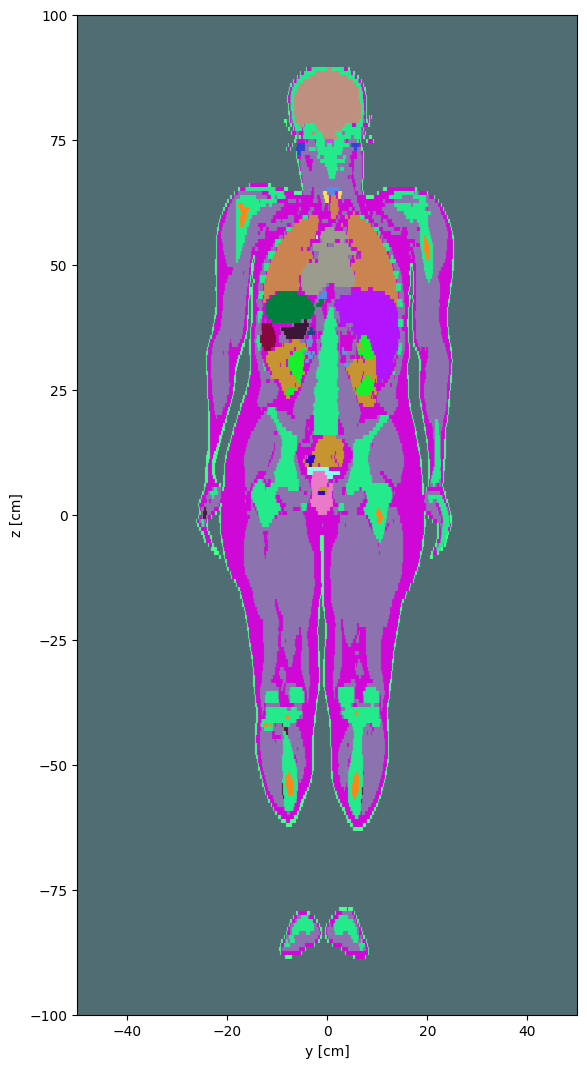

In [12]:
# plot
root.plot(
    basis = 'yz',
    origin = (0, 0, 0),
    color_by = 'cell',
    width=(100,200),
    pixels = (1000, 1000)
)

In [13]:
# Tallies 

In [14]:
# 
organ_universe_ids = list(range(1, 31))                     # 30 organs
universe_filter    = openmc.CellFilter(organ_universe_ids)

# Organ heating tally (total dose from neutrons + photons)
organ_heating_tally = openmc.Tally(name='organ_heating')
organ_heating_tally.filters = [universe_filter]             #
organ_heating_tally.scores  = ['heating']


# Incident fluence tally 
# AP geometry
#plane_filter = openmc.CellFilter(plane_cell_ap)

# LLAT
plane_filter = openmc.CellFilter(plane_cell_llat)

# RLAT
# plane_filter = openmc.CellFilter(plane_cell_rlat)

neutron_filter = openmc.ParticleFilter('neutron')
incident_fluence_tally = openmc.Tally(name='plane_incident_fluence')
incident_fluence_tally.filters = [plane_filter, neutron_filter]
incident_fluence_tally.scores  = ['flux']
# 
tallies = openmc.Tallies()
tallies.append(organ_heating_tally)
tallies.append(incident_fluence_tally)
#tallies.export_to_xml()

In [15]:
# LLAT source defintion 

In [23]:
#
point = openmc.stats.Point(([-40,0,25]))
direction = [0.0,1.0,0.0]
perp_direction = [1.0,0,0.0]
src = openmc.IndependentSource(
    space=point,
    angle = openmc.stats.PolarAzimuthal(
        mu = openmc.stats.Uniform(-0.5,0.5),
        phi = openmc.stats.Uniform(-np.pi*0.7, np.pi*0.7),
        reference_uvw = direction,
        reference_vwu = perp_direction
    ),
    particle = 'neutron',
    energy = openmc.stats.Uniform(2E3, 2E5)
)

#
settings = openmc.Settings()
settings.photon_transport = True
settings.source = src
settings.survival_biasing = True 
# 
settings.particles = 100000     
settings.batches   = 10
settings.seed      = 44
settings.photon_transport = True          
#
settings.run_mode = 'fixed source'
#settings.export_to_xml() 


In [24]:
model = openmc.model.Model()
model.geometry = my_geometry
model.materials = mat
model.settings = settings
#model.tallies = tallies
model.export_to_model_xml()

In [22]:
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [19]:
import openmc
import numpy as np

# Enter Batches number

batches = 10
sp_filename = f'statepoint.{batches}.h5'

with openmc.StatePoint(sp_filename) as sp:
    fluence_tally = sp.get_tally(name='plane_incident_fluence')
    integrated_flux = float(fluence_tally.mean.flatten()[0])
    flux_std        = float(fluence_tally.std_dev.flatten()[0])

    organ_tally = sp.get_tally(name='organ_heating')
    organ_heating_mean = organ_tally.mean.flatten().astype(float)
    organ_heating_std  = organ_tally.std_dev.flatten().astype(float)
########################################################################################
# palne cell volume ( 137 * 180 * 3 )
plane_volume = 73980 # 

fluence_mean = integrated_flux / plane_volume
fluence_std  = flux_std / plane_volume

print(f"   Average fluence Φ      = {fluence_mean:.6e} ± {fluence_std:.2e} n·cm⁻²/source\n")

# ########################################################################################
# Organ masses , (76.43 kg total)
# 
material_data_kg = {
    "skeleton": 10.0678, "skin": 4.9315, "lungs": 0.9715, "brain": 1.6177,
    "spinal cord": 0.1142, "bone marrow": 0.2594, "liver": 1.3605, "kidneys": 0.3329,
    "testes": 0.0302, "bladder": 0.0636, "gall bladder": 0.0149, "heart": 0.7923,
    "salivary glands": 0.0580, "thymus": 0.0173, "thyroid": 0.0094, "esophagus": 0.0255,
    "spleen": 0.2574, "pancreas": 0.1124, "stomach": 0.4287, "adipose": 23.2520,
    "muscle": 29.0920, "breast": 0.0011, "lenses": 0.0002, "eyes": 0.0205,
    "prostate": 0.1012, "adrenals": 0.0045, "small intestine": 1.8561,
    "colon": 0.0783, "upper large intestine": 0.5179, "remainder": 0.0405
}

organ_names = list(material_data_kg.keys())
masses_kg = np.array(list(material_data_kg.values()))

########################################################################################
# Constants & calculations Neutron Effective dose for single energy
#
eV_to_J = 1.60217662e-19
w_R     = 2.5                               # for 1 eV

specific_wt = {
    "bone marrow": 0.12, "upper large intestine": 0.12, "lungs": 0.12, "stomach": 0.12,
    "breast": 0.12, "testes": 0.08, "bladder": 0.04, "esophagus": 0.04,
    "liver": 0.04, "thyroid": 0.04, "skeleton": 0.01, "brain": 0.01,
    "salivary glands": 0.01, "skin": 0.01,
}

D_mean_Gy = (organ_heating_mean * eV_to_J) / masses_kg
D_std_Gy  = (organ_heating_std  * eV_to_J) / masses_kg

DCC_mean_pGy = (D_mean_Gy / fluence_mean) * 1e12
rel_err_D    = D_std_Gy / D_mean_Gy
rel_err_f    = flux_std / integrated_flux
DCC_std_pGy  = DCC_mean_pGy * np.sqrt(rel_err_D**2 + rel_err_f**2)
########################################################################################
print("###### Organ Absorbed Dose Conversion Coefficients (DCC) ######")
for i, name in enumerate(organ_names):
    rel_err_pct = (DCC_std_pGy[i] / DCC_mean_pGy[i]) * 100 if DCC_mean_pGy[i] != 0 else 0.0
    print(f"Organ {i+1:2d} ({name:22s}) : {DCC_mean_pGy[i]:.4e} ± {DCC_std_pGy[i]:.2e} pGy·cm² ({rel_err_pct:5.2f} %)")

# ########################################################################################
# Effective dose (ICRP 103)
#
H_T_mean_Sv = w_R * D_mean_Gy
H_T_std_Sv  = w_R * D_std_Gy

E_mean = 0.0
var_E  = 0.0
remainder_masses = []
remainder_H_mean = []
remainder_H_std  = []

for i, name in enumerate(organ_names):
    if name in specific_wt:
        wt = specific_wt[name]
        E_mean += wt * H_T_mean_Sv[i]
        var_E  += (wt * H_T_std_Sv[i]) ** 2
    else:
        remainder_masses.append(masses_kg[i])
        remainder_H_mean.append(H_T_mean_Sv[i])
        remainder_H_std.append(H_T_std_Sv[i])

if remainder_masses:
    m_rem = np.array(remainder_masses)
    H_rem_mean = np.dot(m_rem, remainder_H_mean) / np.sum(m_rem)
    var_H_rem = np.sum(m_rem**2 * np.array(remainder_H_std)**2) / (np.sum(m_rem)**2)
    E_mean += 0.12 * H_rem_mean
    var_E  += (0.12)**2 * var_H_rem

E_std = np.sqrt(var_E)

EDC_mean_pSv = (E_mean / fluence_mean) * 1e12
EDC_std_pSv  = EDC_mean_pSv * np.sqrt((E_std / E_mean)**2 + rel_err_f**2)
rel_err_EDC_pct = (EDC_std_pSv / EDC_mean_pSv) * 100 if EDC_mean_pSv != 0 else 0.0

print("\n###### Effective Dose Coefficient neutrons ######")
print(f"E/Φ = {EDC_mean_pSv:.4e} ± {EDC_std_pSv:.2e} pSv·cm² ({rel_err_EDC_pct:5.2f} %)")

LookupError: Unable to get Tally